# Mixup
It is a data augmentation technique where a new sample are formed by linearly combined two random samples, the new label is also the linear combination of labels of the two selected samples.

In [ ]:
# Check colab's gpu
!nvidia-smi

Tue Nov 11 12:26:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
batch_size = 128
torch.manual_seed(0)
# dataset is RGB ie. 3 channels
# images in the dataset have varying sizes
# mean and std value used for normalisartion follows standard practice values of imagenet since ResNet that we are using is pretrained on imagenet
# ResNet50 req dimensions of images to be 224

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

train_dataset = datasets.Flowers102('data', split = 'train', download=True, transform = transform)
test_dataset = datasets.Flowers102('data', split = 'test', download=True, transform = transform)
validation_dataset = datasets.Flowers102('data', split = 'val', download=True, transform = transform)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)


torch.manual_seed(1)

100%|██████████| 345M/345M [00:19<00:00, 17.4MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.41MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 40.2MB/s]


torch.Size([128, 3, 224, 224])


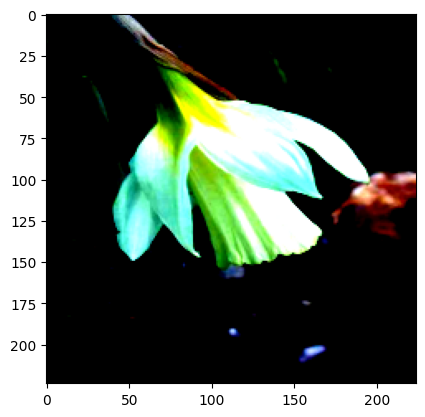

In [ ]:
# select a random sample
images, labels = next(iter(train_loader))
print(images.shape)
plt.imshow(images[0].permute(1, 2, 0))

# MixUp data augmentation

In [ ]:
# Get exact class distribution for train dataset to make sure class is balanced
def get_exact_class_distribution(dataset):
    class_counts = torch.zeros(102, dtype=torch.long)
    for i in range(len(dataset)):
        _, label = dataset[i]
        class_counts[label] += 1
    return class_counts

# Get counts for each dataset
train_class_counts = get_exact_class_distribution(train_dataset)
val_class_counts = get_exact_class_distribution(validation_dataset)
test_class_counts = get_exact_class_distribution(test_dataset)

# Print class distribution for training set
print("=== TRAINING SET CLASS DISTRIBUTION ===")
for class_id in range(102):
    count = train_class_counts[class_id].item()
    print(f"Class {class_id}: {count} samples")

# Total counts
print(f"\n=== TOTAL SAMPLES ===")
print(f"Training set: {len(train_dataset)} samples")

=== TRAINING SET CLASS DISTRIBUTION ===
Class 0: 10 samples
Class 1: 10 samples
Class 2: 10 samples
Class 3: 10 samples
Class 4: 10 samples
Class 5: 10 samples
Class 6: 10 samples
Class 7: 10 samples
Class 8: 10 samples
Class 9: 10 samples
Class 10: 10 samples
Class 11: 10 samples
Class 12: 10 samples
Class 13: 10 samples
Class 14: 10 samples
Class 15: 10 samples
Class 16: 10 samples
Class 17: 10 samples
Class 18: 10 samples
Class 19: 10 samples
Class 20: 10 samples
Class 21: 10 samples
Class 22: 10 samples
Class 23: 10 samples
Class 24: 10 samples
Class 25: 10 samples
Class 26: 10 samples
Class 27: 10 samples
Class 28: 10 samples
Class 29: 10 samples
Class 30: 10 samples
Class 31: 10 samples
Class 32: 10 samples
Class 33: 10 samples
Class 34: 10 samples
Class 35: 10 samples
Class 36: 10 samples
Class 37: 10 samples
Class 38: 10 samples
Class 39: 10 samples
Class 40: 10 samples
Class 41: 10 samples
Class 42: 10 samples
Class 43: 10 samples
Class 44: 10 samples
Class 45: 10 samples
Clas

**Each class has exactly 10 sample, no imbalance hence go can ahead with mixup**

In [ ]:
def mixup_data(x, y, alpha=0.2):
    """Standard Mixup implementation"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


In [ ]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss <= self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
# Functions for training and testing

def train_loop(dataloader, model, loss_fn, optimizer, mixup_alpha=0.2):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, train_correct = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # creating new samples
        mixed_X, y_a, y_b, lam = mixup_data(X, y, mixup_alpha)

        pred = model(mixed_X)
        loss = mixup_criterion(loss_fn, pred, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        # Calculate accuracy on original images for monitoring
        with torch.no_grad():
            original_pred = model(X)
            train_correct += (original_pred.argmax(1) == y).type(torch.float).sum().item()

    train_loss /= num_batches
    train_correct /= size

    return train_loss, train_correct

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            test_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_correct /= size

    return test_loss, test_correct

# Training to find best alpha

In [ ]:
# To support validation process
def validation_loop(dataloader, model, loss_fn): # Same as when training baseline model
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            val_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss /= num_batches
    val_correct /= size

    return val_loss, val_correct


In [ ]:
# Test different alpha values using validation set
alpha_values = [0.2, 0.4, 0.6, 0.8]
validation_results = {}

for alpha in alpha_values:
    print(f"\n{'='*50}")
    print(f"Training with Mixup alpha = {alpha}")
    print(f"{'='*50}")

    # Reset model for each alpha
    model = models.resnet50(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 102)
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.0005, weight_decay=0.01)
    early_stopper = EarlyStopper(patience=5, min_delta=0.001)

    best_val_acc = 0
    train_acc_history = []
    val_acc_history = []

    for t in range(50):  # Reduced epochs for faster alpha search
        model.train()
        train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer, mixup_alpha=alpha)

        model.eval()
        val_loss, val_acc = validation_loop(val_loader, model, loss_fn)

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        # Track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(f"Alpha {alpha} | Epoch {t+1}: Train: {100*train_acc:>0.2f}%, Val: {100*val_acc:>0.2f}%")

        if early_stopper.early_stop(val_loss):
            print(f"Early stopping at epoch {t+1}")
            break

    # Store results for this alpha
    validation_results[alpha] = {
        'best_val_acc': best_val_acc,
        'final_val_acc': val_acc,
        'final_train_acc': train_acc,
        'val_acc_history': val_acc_history,
        'train_acc_history': train_acc_history,
        'epochs_trained': t+1
    }

# Find best alpha based on validation performance
best_alpha = max(validation_results.keys(), key=lambda x: validation_results[x]['best_val_acc'])
best_val_accuracy = validation_results[best_alpha]['best_val_acc']

print(f"\n{'='*60}")
print("VALIDATION RESULTS - ALPHA SELECTION")
print(f"{'='*60}")
print("Alpha | Best Val Acc | Final Val Acc | Final Train Acc | Epochs")
print(f"{'-'*60}")
for alpha in alpha_values:
    r = validation_results[alpha]
    print(f"{alpha:5.1f} | {100*r['best_val_acc']:12.2f}% | {100*r['final_val_acc']:11.2f}% | {100*r['final_train_acc']:14.2f}% | {r['epochs_trained']:6}")

print(f"\n BEST ALPHA: {best_alpha} (Validation Accuracy: {100*best_val_accuracy:.2f}%)")


Training with Mixup alpha = 0.2
Alpha 0.2 | Epoch 1: Train: 5.10%, Val: 9.80%
Alpha 0.2 | Epoch 2: Train: 22.16%, Val: 31.27%
Alpha 0.2 | Epoch 3: Train: 54.51%, Val: 48.92%
Alpha 0.2 | Epoch 4: Train: 72.06%, Val: 61.18%
Alpha 0.2 | Epoch 5: Train: 83.92%, Val: 69.90%
Alpha 0.2 | Epoch 6: Train: 89.71%, Val: 74.61%
Alpha 0.2 | Epoch 7: Train: 91.47%, Val: 74.31%
Alpha 0.2 | Epoch 8: Train: 93.14%, Val: 76.96%
Alpha 0.2 | Epoch 9: Train: 95.49%, Val: 78.33%
Alpha 0.2 | Epoch 10: Train: 96.18%, Val: 79.61%
Alpha 0.2 | Epoch 11: Train: 96.47%, Val: 80.98%
Alpha 0.2 | Epoch 12: Train: 98.24%, Val: 82.55%
Alpha 0.2 | Epoch 13: Train: 98.43%, Val: 82.06%
Alpha 0.2 | Epoch 14: Train: 98.53%, Val: 82.35%
Alpha 0.2 | Epoch 15: Train: 98.33%, Val: 83.43%
Alpha 0.2 | Epoch 16: Train: 99.02%, Val: 83.73%
Alpha 0.2 | Epoch 17: Train: 99.02%, Val: 83.33%
Alpha 0.2 | Epoch 18: Train: 98.73%, Val: 84.51%
Alpha 0.2 | Epoch 19: Train: 99.12%, Val: 84.71%
Alpha 0.2 | Epoch 20: Train: 99.41%, Val: 83.92

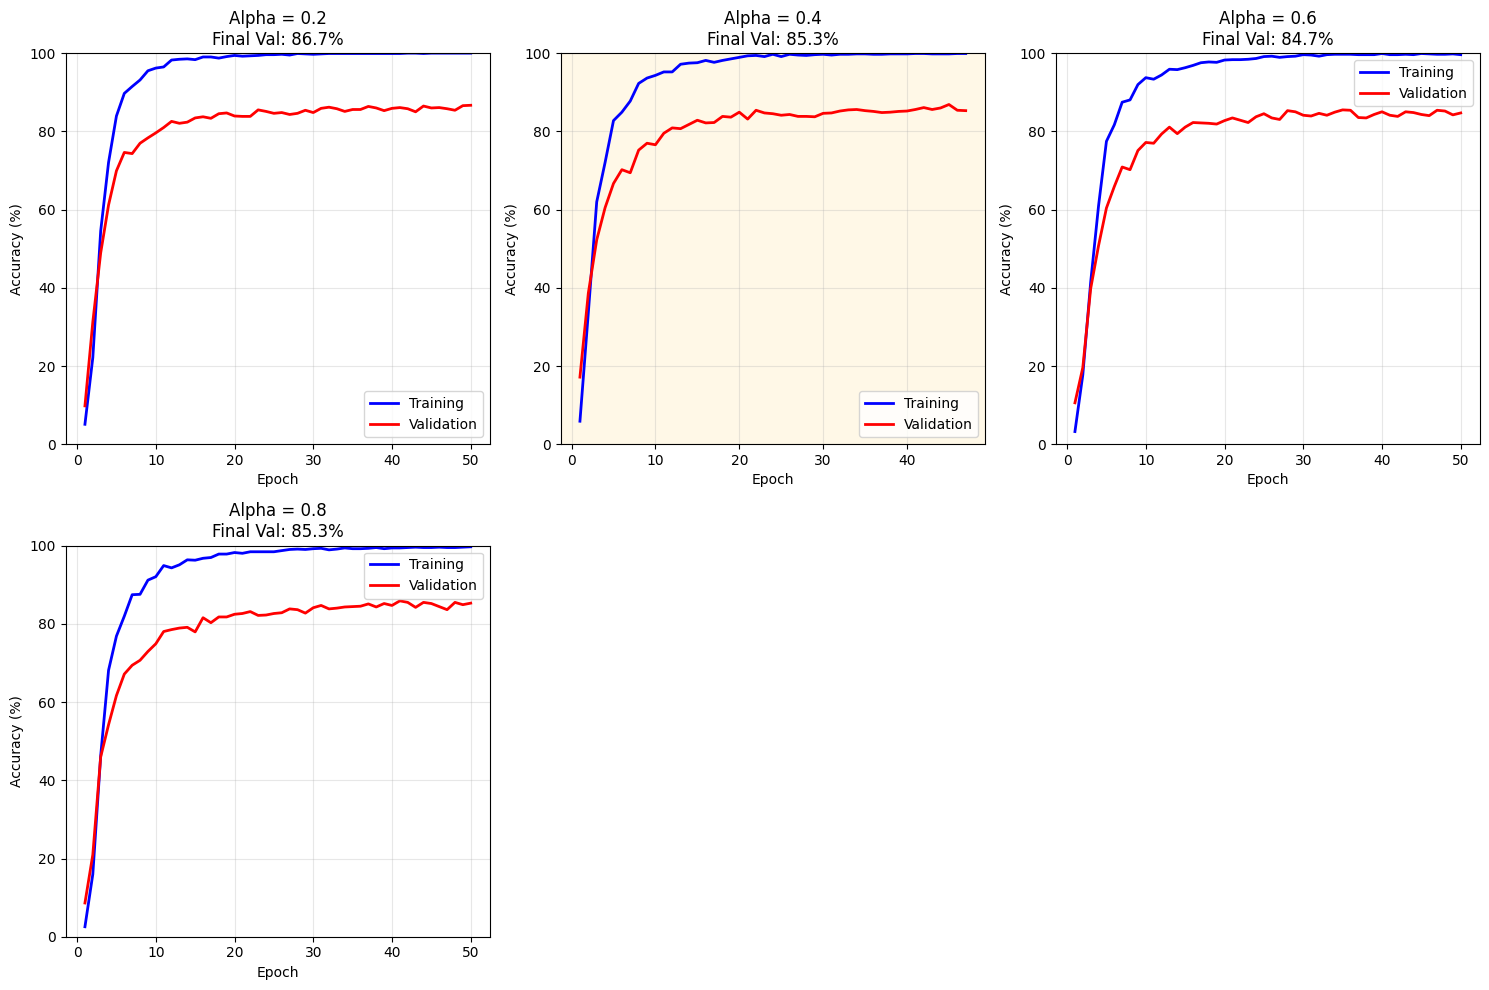

In [ ]:
plt.figure(figsize=(15, 10))

# Plot training and validation curves for each alpha
max_epochs = max(len(validation_results[alpha]['train_acc_history']) for alpha in alpha_values)

for i, alpha in enumerate(alpha_values):
    plt.subplot(2, 3, i+1)
    history = validation_results[alpha]

    epochs = range(1, len(history['train_acc_history']) + 1)
    plt.plot(epochs, [100*acc for acc in history['train_acc_history']],
             'b-', linewidth=2, label='Training')
    plt.plot(epochs, [100*acc for acc in history['val_acc_history']],
             'r-', linewidth=2, label='Validation')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Alpha = {alpha}\nFinal Val: {100*history["final_val_acc"]:.1f}%')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)

    # Highlight best alpha
    if alpha == best_alpha:
        plt.gca().patch.set_facecolor('#FFF8E7')  # Light yellow background

plt.tight_layout()
plt.show()

# Final training and testing

In [16]:
# Train final model with best alpha on combined train+val data
best_alpha = 0.4
print(f"\n{'='*50}")
print(f"FINAL TRAINING with best alpha = {best_alpha}")
print(f"{'='*50}")

full_train_dataset = ConcatDataset([train_dataset, validation_dataset])
final_train_loader = DataLoader(full_train_dataset, batch_size=128, shuffle=True, drop_last=True)

# Final model
final_model = models.resnet50(pretrained=True)
for param in final_model.parameters():
    param.requires_grad = False
num_ftrs = final_model.fc.in_features
final_model.fc = nn.Linear(num_ftrs, 102)
final_model = final_model.to(device)

final_optimizer = optim.Adam(final_model.fc.parameters(), lr=0.0005, weight_decay=0.01)
final_early_stopper = EarlyStopper(patience=5, min_delta=0.001)

print(f"Training final model on {len(full_train_dataset)} samples (train + val)")
print(f"Using Mixup alpha = {best_alpha}")

final_train_acc_history = []
final_test_acc_history = []
loss_fn = nn.CrossEntropyLoss()

for t in range(100):
    final_model.train()
    train_loss, train_acc = train_loop(final_train_loader, final_model, loss_fn, final_optimizer, mixup_alpha=best_alpha)

    final_model.eval()
    test_loss, test_acc = test_loop(test_loader, final_model, loss_fn)

    final_train_acc_history.append(train_acc)
    final_test_acc_history.append(test_acc)

    print(f"Final Model | Epoch {t+1}: Train: {100*train_acc:>0.2f}%, Test: {100*test_acc:>0.2f}%")

    if final_early_stopper.early_stop(test_loss):
        print("Early stopping triggered for final model!")
        break

# Final results
best_test_accuracy = max(final_test_acc_history)
final_test_accuracy = test_acc

print(f"\n{'='*50}")
print("FINAL TEST RESULTS")
print(f"{'='*50}")
print(f"Best Alpha Selected: {best_alpha}")
print(f"Best Validation Accuracy: {100*best_val_accuracy:.2f}%")
print(f"Final Test Accuracy: {100*final_test_accuracy:.2f}%")
print(f"Best Test Accuracy: {100*best_test_accuracy:.2f}%")


FINAL TRAINING with best alpha = 0.4
Training final model on 2040 samples (train + val)
Using Mixup alpha = 0.4
Final Model | Epoch 1: Train: 9.66%, Test: 18.20%
Final Model | Epoch 2: Train: 41.37%, Test: 50.71%
Final Model | Epoch 3: Train: 66.96%, Test: 67.08%
Final Model | Epoch 4: Train: 76.81%, Test: 73.02%
Final Model | Epoch 5: Train: 79.66%, Test: 74.84%
Final Model | Epoch 6: Train: 83.73%, Test: 78.91%
Final Model | Epoch 7: Train: 84.66%, Test: 80.37%
Final Model | Epoch 8: Train: 87.84%, Test: 81.31%
Final Model | Epoch 9: Train: 86.91%, Test: 81.74%
Final Model | Epoch 10: Train: 88.68%, Test: 83.02%
Final Model | Epoch 11: Train: 88.63%, Test: 83.01%
Final Model | Epoch 12: Train: 89.95%, Test: 83.83%
Final Model | Epoch 13: Train: 90.25%, Test: 84.29%
Final Model | Epoch 14: Train: 90.74%, Test: 84.47%
Final Model | Epoch 15: Train: 91.23%, Test: 85.77%
Final Model | Epoch 16: Train: 91.81%, Test: 84.11%
Final Model | Epoch 17: Train: 91.27%, Test: 85.75%
Final Model |